In [216]:
!pip install folium
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from folium.plugins import HeatMap
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [217]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [218]:
path = "/content/drive/MyDrive/Project_Machine_Learning/Praktikum_Mandiri_11/Data/"

df = pd.read_csv(path + "911.csv")

df

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1
...,...,...,...,...,...,...,...,...,...
95,40.095320,-75.193482,CHELTENHAM AVE & DELPHINE RD; SPRINGFIELD; 201...,19038.0,Traffic: VEHICLE ACCIDENT -,2015-12-10 21:58:11,SPRINGFIELD,CHELTENHAM AVE & DELPHINE RD,1
96,40.151476,-75.396624,MARK LN & IVY CIR; LOWER PROVIDENCE; Station ...,19403.0,EMS: CVA/STROKE,2015-12-10 22:03:14,LOWER PROVIDENCE,MARK LN & IVY CIR,1
97,40.127611,-75.379915,HEMLOCK RD & SHIRLEY LN; WEST NORRITON; Stati...,19403.0,EMS: FALL VICTIM,2015-12-10 22:24:21,WEST NORRITON,HEMLOCK RD & SHIRLEY LN,1
98,40.284455,-75.574528,CEDAR LN & WILLOW LN; NEW HANOVER; Station 33...,19525.0,EMS: SEIZURES,2015-12-10 22:22:38,NEW HANOVER,CEDAR LN & WILLOW LN,1


In [219]:
df.isnull().sum()

,0
lat,0
lng,0
desc,0
zip,14
title,0
timeStamp,0
twp,0
addr,0
e,0


In [220]:
df_clean = df.dropna(subset=["zip"])

In [221]:
df.duplicated().sum()

np.int64(0)

In [222]:
# Ambil kolom GPS
gps = df_clean[["lat", "lng"]].values

# Normalisasi data agar DBSCAN lebih stabil
scaled = StandardScaler().fit_transform(gps)

# Menentukan nilai eps dan min_samples (awal)
eps = 0.05     # bisa dituning
min_samples = 20

dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(scaled)
labels = dbscan.labels_

df_clean["cluster"] = labels
df_clean.to_csv("911_dbscan_result.csv", index=False)

/tmp/ipython-input-2266166582.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["cluster"] = labels


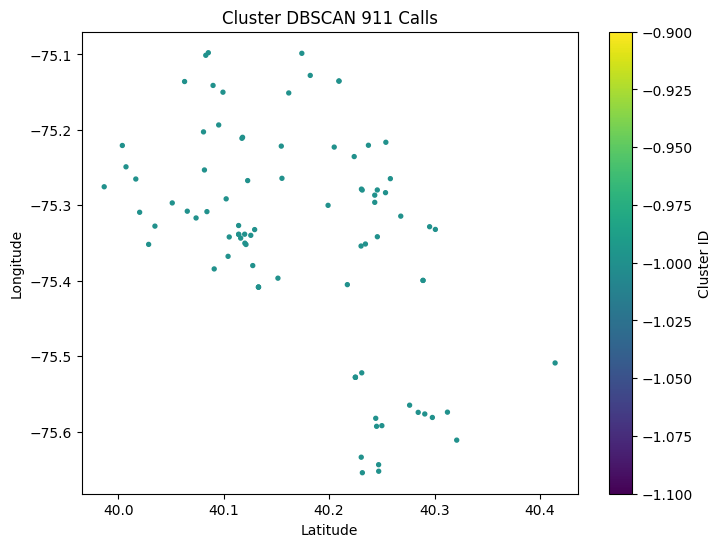

In [223]:
plt.figure(figsize=(8,6))
plt.scatter(df_clean["lat"], df_clean["lng"], c=df_clean["cluster"], s=8)
plt.title("Cluster DBSCAN 911 Calls")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.colorbar(label="Cluster ID")
plt.show()

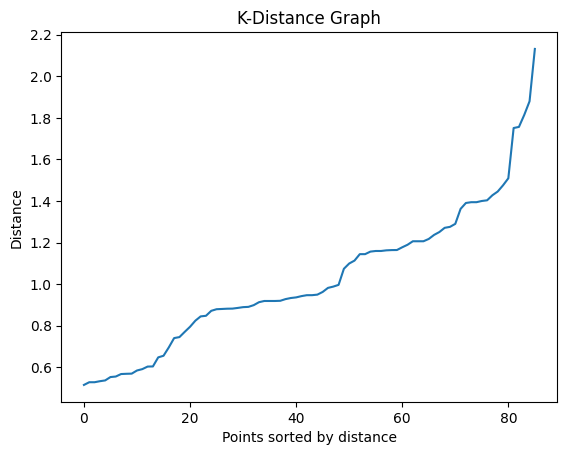

In [224]:
k = 20
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(scaled)
distances, indices = nbrs.kneighbors(scaled)

distances = np.sort(distances[:, k-1])
plt.plot(distances)
plt.title("K-Distance Graph")
plt.ylabel("Distance")
plt.xlabel("Points sorted by distance")
plt.show()

In [225]:
clusters = df_clean["cluster"].unique()
print("Daftar cluster:", clusters)
print("Jumlah Noise (-1):", sum(df_clean["cluster"] == -1))
print("\nJumlah titik tiap cluster:")
print(df_clean["cluster"].value_counts())

Daftar cluster: [-1]
Jumlah Noise (-1): 86

Jumlah titik tiap cluster:
cluster
-1    86
Name: count, dtype: int64


In [226]:
# Buat peta dasar USA (atau ubah sesuai wilayah datamu)
peta_911 = folium.Map(location=[df_clean["lat"].mean(), df_clean["lng"].mean()], zoom_start=10)

# Heatmap format [lat, lng, value]
# Disini value = 1 (semua titik dianggap 1 kejadian)
data_heatmap = df_clean[['lat', 'lng']].copy()
data_heatmap['value'] = 1   # bisa diganti dengan bobot lain
heatmap_list = data_heatmap[['lat','lng','value']].values.tolist()

HeatMap(
    heatmap_list,
    radius=12,
    blur=15,
    max_zoom=10
).add_to(peta_911)

peta_911   # langsung tampil tanpa save

In [227]:
# Titik tengah peta
center = [df_clean["lat"].mean(), df_clean["lng"].mean()]
m = folium.Map(location=center, zoom_start=11)

# Tambahkan titik ke peta
for _, row in df_clean.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=2,
        color="red" if row["cluster"]==-1 else "blue",
        fill=True,
    ).add_to(m)

m.save("911_cluster_map.html")
m
